# This is a tutorial for doing the pileup analysis

## Imports

In [1]:
import os, sys
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
BASE = "../"
sys.path.append(BASE)
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 1
import utility.functions
import src.analysis
import src.dataset
import src.plots
import src.simulation
import numpy as np
import src.analysis as an
import src.dataset as ds
import torch
from scipy.stats import norm
from utility.double_beta_spectrum import pdf_ratio2b
import utility.functions as fn
import uproot
from scipy.signal.windows import flattop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(sys.executable)
print(torch.__version__)

/opt/homebrew/opt/python@3.13/bin/python3.13
2.11.0


## Choose analysis parameters

In [29]:
meas_name = "000813_20230628T161508"
channel = 83
sampling_rate = 2000
acceptance = 0.9
N_sigma = norm.ppf(1 - (1 - acceptance) * 100 / 100) #number of sigma corresponding to the desired acceptance
signal_amp = 8.35e-3
#define the time and ratio grid for the analysis
t_min, t_max, N_t = 0, 8e-4, 100
r_min, r_max, N_r = 0., .5, 100
#get the corresponding ratio distribution 
ratio_distribution = pdf_ratio2b(np.linspace(r_min, r_max, N_r))
ratio_distribution /= np.mean(ratio_distribution)

window_size = 800 #size of the window used for the analysis, should be the same as the one used for the NPS computation
n_trials=200 #number of trials for the optimization of the filters

## Load the meanpulse and Noise power spectrum
if they are not already compute, look build_meanpulses.py and build_NPS.py to compute them

In [23]:
#load the meanpulse
meanpulse = np.fromfile(f"{BASE}/NuoveAnalisiArgonauts_m204/000204_20260405T115934_0{channel}_000.bin_edmean.bin")
print(len(meanpulse))
if len(meanpulse) > window_size:
    meanpulse = meanpulse[np.argmax(meanpulse) - window_size//2 : np.argmax(meanpulse) + window_size//2]
#load the NPS
nps = np.fromfile(f"{BASE}/NuoveAnalisiArgonauts_m204/000204_20260405T115934_0{channel}_000.bin_spec.bin")

sampling_time = window_size / sampling_rate
nps *= 1e-12
#nps /= 910**2
#nps /= window_size**2
#nps /= (1 / sampling_time)  # Normalize by sampling rate


f_argonauts_windowing = window_size / np.sum(np.hamming(window_size) ** 2)
nps *= f_argonauts_windowing
#nps *= (8. / 3.)

print(f_argonauts_windowing)
sqrt_nps = np.sqrt(nps)

#nps /= (window_size * sampling_rate)  # Normalize by window size and sampling rate



800
2.5194549159289386


In [ ]:
filepath_ANPS = f"/Users/albertozanelli/Desktop/Tesi_Erasmus/Pileup_Analysis-update-from-MIT/Processed/m204_ANPS/Processed_20260405T115934_000204_{channel}.root"
filepath_MeanPulse = f"/Users/albertozanelli/Desktop/Tesi_Erasmus/Pileup_Analysis-update-from-MIT/Processed/m204_AP/Processed_20260405T115934_000204_{channel}_new.root"
with uproot.open(filepath_ANPS) as f, uproot.open(filepath_MeanPulse) as f2:
    # 1. Estrazione Meanpulse
    hist_pulse = f2["averagepulse_ap_medianAP"]
    meanpulse_octopus = np.asarray(hist_pulse.values(), dtype=float)

    # 2. Estrazione NPS
    tgraph_nps = f["averagepowerspectrum_anps_medianpower"]

    # 2. .values() restituisce (x, y). Prendiamo solo la y (indice 1)
    y_vals = tgraph_nps.values()

    # 3. Trasformiamo in array NumPy ed eseguiamo la concatenazione
    nps_octopus = np.asarray(y_vals, dtype=float)
    nps_octopus = np.concatenate([nps_octopus, nps_octopus[-2:0:-1]])
    
    window_ft = flattop(window_size)
    f_octopus_windowing = window_size / np.sum(window_ft**2)
    print(f_octopus_windowing)
    
    nps_octopus *= f_octopus_windowing
    nps_octopus *= window_size**2
    nps_octopus *= (1 / sampling_time)
    print(sampling_time)

    sqrt_nps_octopus = np.sqrt(nps_octopus)
    sqrt_nps_octopus /= 910
    

    print(len(nps_octopus))
    #nps= nps_octopus

5.71427008015353
0.4
800


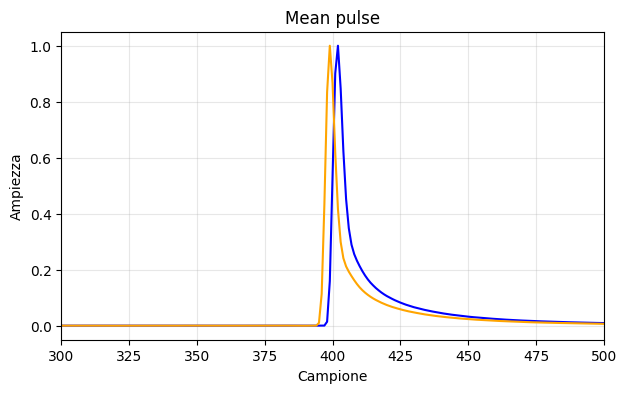

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(meanpulse_octopus, color="blue")
plt.plot(meanpulse, color="orange")
plt.xlabel("Campione")
plt.ylabel("Ampiezza")
plt.title("Mean pulse")
plt.grid(True, alpha=0.3)
plt.xlim(300, 500)
plt.show()

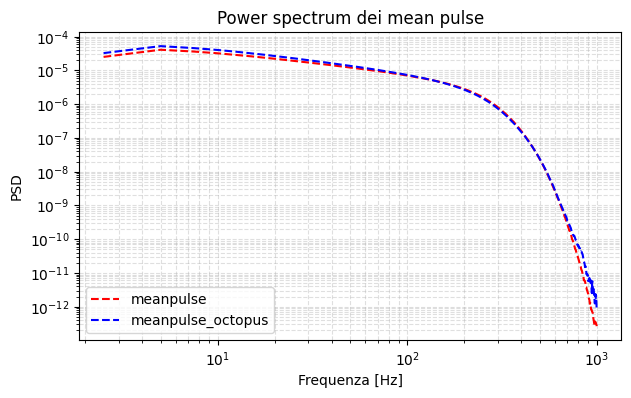

In [26]:
# Noise power spectrum / power spectrum of the mean pulses
def compute_psd(signal, sampling_rate, window_fct=np.hanning):
    signal = np.asarray(signal, dtype=float)
    signal = signal - np.mean(signal)

    win = window_fct(len(signal))
    xw = signal * win

    fft_vals = np.fft.rfft(xw)
    psd = (np.abs(fft_vals) ** 2) / (sampling_rate * len(signal))
    freq = np.fft.rfftfreq(len(signal), d=1 / sampling_rate)

    return freq, psd

freq_mp, psd_mp = compute_psd(meanpulse, sampling_rate)
freq_oct, psd_oct = compute_psd(meanpulse_octopus, sampling_rate)

plt.figure(figsize=(7, 4))
plt.loglog(freq_mp[1:], psd_mp[1:], linestyle="--", color="red", label="meanpulse")
plt.loglog(freq_oct[1:], psd_oct[1:], linestyle="--", color="blue", label="meanpulse_octopus")
plt.xlabel("Frequenza [Hz]")
plt.ylabel("PSD")
plt.title("Power spectrum dei mean pulse")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()

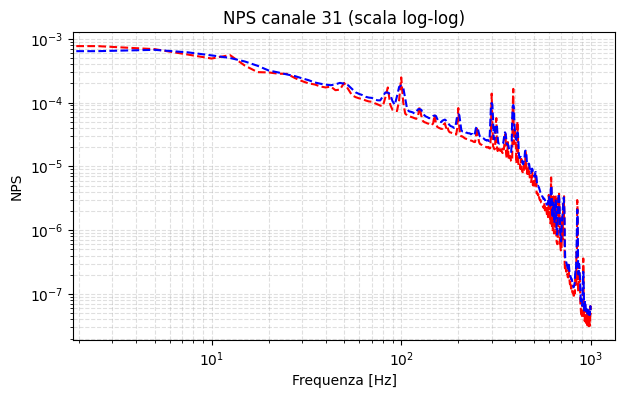

In [7]:
freq = np.fft.fftfreq(len(nps), d=1/sampling_rate)

mask = freq >= 0  # evita f=0 e frequenze negative per scala log
#print(len(sqrt_nps[mask]))
plt.figure(figsize=(7, 4))
#plt.loglog(freq[mask], nps[mask])
plt.loglog(freq[mask], nps[mask], linestyle='--', color='red')
plt.loglog(freq[mask], nps_octopus[mask], linestyle='--', color='blue')
plt.xlabel("Frequenza [Hz]")
plt.ylabel("NPS")
plt.title(f"NPS canale {channel} (scala log-log)")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()



## Compute the optimal filter

In [18]:
#meanpulse = meanpulse_octopus
#nps = nps_octopus

S, w, H_unit = an.compute_H(meanpulse, nps, np.hanning, sampling_rate=sampling_rate)

In [19]:
def compute_sigma_OF(S, nps, sampling_rate, N):
    """
    Calcola la deviazione standard (sigma) del Filtro Ottimo.

    Args:
        S (torch.Tensor o array): FFT del meanpulse (output diretto di np.fft.fft, NON normalizzato).
        nps (torch.Tensor o array): Noise Power Spectrum in V^2/Hz (già corretto per il windowing).
        sampling_rate (float): Frequenza di campionamento in Hz.
        N (int): Numero di campioni nella finestra (window_size).

    Returns:
        float: La deviazione standard analitica del filtro ottimo (sigma).
    """
    S = torch.tensor(S, dtype=torch.cfloat)
    nps = torch.tensor(nps, dtype=torch.cfloat)
    
    # 1. Calcola il rapporto |S|^2 / NPS per ogni bin di frequenza
    absS2_over_nps = (S.abs() ** 2) / nps
    
    # 2. Somma su tutte le frequenze
    sum_term = torch.sum(absS2_over_nps)
    
    # 3. Applica i fattori di scala fisici per la DFT (f_s * N) al numeratore
    var_OF = (sampling_rate * N) / sum_term
    
    # 4. Estrai la radice quadrata per ottenere sigma
    sigma_OF = var_OF.real**0.5
    
    return float(sigma_OF)


sigma_analytic = an.compute_sigma_OF(S, nps)


print(f"Analytic sigma: {sigma_analytic*1000:.8f} mV")
print(f"signal_amp: {signal_amp*1000:.4f} mV")
print(f"SNR: {signal_amp / (sigma_analytic):.2f}")

Analytic sigma: 0.16631325 mV
signal_amp: 8.3500 mV
SNR: 50.21


## Convert the relevant arrays to torch tensors and move them to the appropriate device (CPU or GPU)

In [20]:
S_torch = torch.tensor(S, dtype=torch.cfloat, device=device)
H_unit_torch = torch.tensor(H_unit, dtype=torch.cfloat, device=device)
w_torch = torch.tensor(w, dtype=torch.cfloat, device=device)
nps_torch = torch.tensor(nps, dtype=torch.cfloat, device=device)
signal_amp_torch = torch.tensor(signal_amp, dtype=torch.float32, device=device)
t_torch = torch.linspace(t_min, t_max, N_t, dtype=torch.cfloat, device=device)
r_torch = torch.linspace(r_min, r_max, N_r, dtype=torch.cfloat, device=device)
ratio_distribution_torch = torch.tensor(ratio_distribution, dtype=torch.cfloat, device=device)

## Optimize the filters for minimal misidentification rate (J_value)

In [21]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
"""f1_t, f2_t, lam, W_unit, J_values, lambda_values = an.optimize_filters_wiener_lambda(
    S_torch, w_torch, t_torch, r_torch, nps_torch,
    signal_amp_torch, ratio_distribution_torch, N_sigma=N_sigma,
    activation_fct=torch.abs,
    f1_init=None, f2_init=None,
    lambda_init=0.04, n_trials=800
) 
"""
f1_t, f2_t, J_values = an.optimize_filters(S_torch, H_unit_torch, w_torch, t_torch, r_torch, nps_torch,
                                           signal_amp_torch, ratio_distribution_torch, N_sigma=N_sigma, 
                                           activation_fct = torch.abs,
                                           f1_init = None, f2_init = None,
                                           n_trials=300, use_interp = True, verbose=True)


Step 0: J = 0.874536
Step 10: J = 0.582378
Step 20: J = 0.430938
Step 30: J = 0.372142
Step 40: J = 0.340835
Step 50: J = 0.320635
Step 60: J = 0.306767
Step 70: J = 0.297025
Step 80: J = 0.289964
Step 90: J = 0.284684
Step 100: J = 0.280648
Step 110: J = 0.277523
Step 120: J = 0.275088
Step 130: J = 0.273163
Step 140: J = 0.271627
Step 150: J = 0.270394
Step 160: J = 0.269408
Step 170: J = 0.268611
Step 180: J = 0.267972
Step 190: J = 0.267455
Step 200: J = 0.267047
Step 210: J = 0.266724
Step 220: J = 0.266471
Step 230: J = 0.266277
Step 240: J = 0.266131
Step 250: J = 0.266025
Step 260: J = 0.265955
Step 270: J = 0.265912
Step 280: J = 0.265888
Step 290: J = 0.265878
Final: J = 0.265877


## Save the results

In [12]:
f1_opt,f2_opt = f1_t.cpu().numpy(), f2_t.cpu().numpy()
np.save(f"{BASE}/outputs/training_Js/channel_{channel}/J_{int(acceptance * 100):d}_RUN14_meas204", np.array(J_values))
np.save(f"{BASE}/outputs/Pileup_filter_functions/channel_{channel}/functions_eff{int(acceptance * 100):d}_RUN14_meas204",np.array([f1_opt, f2_opt]))

FileNotFoundError: [Errno 2] No such file or directory: '..//outputs/training_Js/channel_31/J_90_RUN14_meas204.npy'

# BI estimation
A proxi for the BI can be optained from the Misidentification rate (J_value) 

In [17]:
BI_estimate = J_values[-1] * fn.K #Here K is a constant that depends on crystal size, Mo-2b2n decay rate, maximum delay studied,...
BI_estimate

6.750654111657878e-05

# Compute the Background Index using injected pulses
If enough statistics is available, the BI can be computed directly from the injected pulse datasets, by applying the optimized filters and counting the number of misidentified pileup events.

## Load the dataset
path_pos_single and path_pos_pileup are the paths to the position files for the single pulse and pileup datasets, respectively. They contain the relevent informations for the injection (position in the raw file to inject pulse , amplitudes, delay, smearing,...). Those data are created by montecarlo from IJClab code.

In [ ]:
#load the pulse to be injected
meanpulse_inj = np.load(f"{BASE}/outputs/meanpulses_build/pos_pulses_rawdata/average_pulse_channel{channel}.npy")
#load the single pulse dataset
dataset_single_name = "pup_n1-d0_000813_20230628T161508"
file_path_single, path_pos_single = ds.find_files(meas_name, dataset_single_name, channel,
                                                  specific_subdir="RUN9_pulse_injected_new/")
data_single = ds.CachedBinaryDataset_withgenerated(file_path_single, path_pos_single, window_size,
                                                   pulse=meanpulse_inj,
                                                   n_windows=15999, win_shift=0)
#load the pileup pulse dataset
dataset_pileup_name = "pup_n1-d8_000813_20230628T161508"
file_path_pileup, path_pos_pileup = ds.find_files(meas_name, dataset_pileup_name, channel,
                                                  specific_subdir="RUN9_pulse_injected_new/")
data_pileup = ds.CachedBinaryDataset_withgenerated(file_path_pileup, path_pos_pileup, window_size,
                                                   pulse=meanpulse_inj,
                                                   n_windows=15999, win_shift=0)

FileNotFoundError: [Errno 2] No such file or directory: '..//outputs/meanpulses_build/pos_pulses_rawdata/average_pulse_channel71.npy'

## Compute the Background Index

tensor(6.8572) tensor(0.7418)


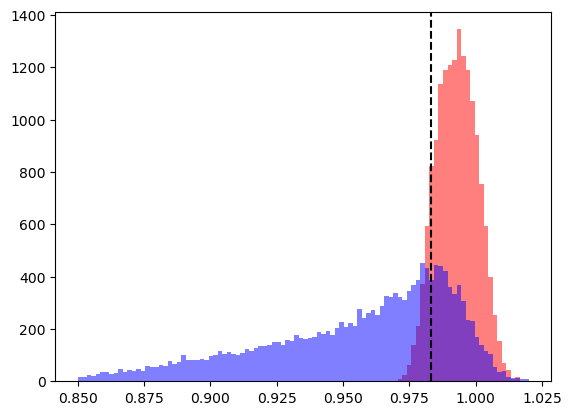

In [ ]:
BI, rp, PSD_pileup, PSD_single, Amp_1_pileup, Amp_2_pileup, Amp_1_single, Amp_2_single = an.compute_BI_torch(
            data_pileup,
            data_single,
            acceptance,
            H_unit_torch,
            f1_t,
            f2_t,
            window_fct = np.hanning,
            compute_uncertainty = False,
            batch_size = 2048,
            use_loader = False,
            full_output = True
        )
print(BI*1e5, rp)
plt.hist(PSD_single, bins=100,range=(0.85,1.02), alpha=0.5, label="Single pulse", color="red")
plt.hist(PSD_pileup, bins=100,range=(0.85,1.02), alpha=0.5, label="Pileup pulse", color="blue")
cut = np.percentile(PSD_single,(1-acceptance)*100)
plt.axvline(cut, color="black", linestyle="--", label="Threshold")